In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main import ModelClass, constraints

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint

from IPython.display import display, Math

from plots import plot_series

model = ModelClass()

par = model.par
sol = model.sol
sim = model.sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


This model is used to find a certain condition. Currently, I just minimize the change in average wage level, because it was not easy to get by just setting parameters.

In [8]:
optimizer_trials = 1000

eps = 1e-8

A = np.array([
    [0, 0, 0, -1, 1, 0, 0, 0, 0, 0],  # theta_h_y - theta_l_y
    [0, 0, 0, 0, 0, -1, 1, 0, 0, 0]
])

lb = np.array([
    eps,
    eps
])

ub = np.array([
    np.inf,
    np.inf
])

linear_constraint = LinearConstraint(A, lb, ub)

c:\Users\per.eco\AppData\Local\anaconda3\Lib\site-packages\scipy\optimize\_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Success: True
Message: `xtol` termination condition is satisfied.
Objective value: -4.035355000178043
Optimized parameters:
par.A =  4.205947294066126
par.N_y =  45.17484498216316
par.alpha =  0.9875864860959839
par.theta_l_y =  0.6579222324315198
par.theta_h_y =  4.541042166093866
par.theta_l_o =  3.803963057781885
par.theta_h_o =  4.010836709303394
par.mu_y =  4.211000849002498
par.rho_l =  0.9567861096023205
par.c =  0.10743564864050532


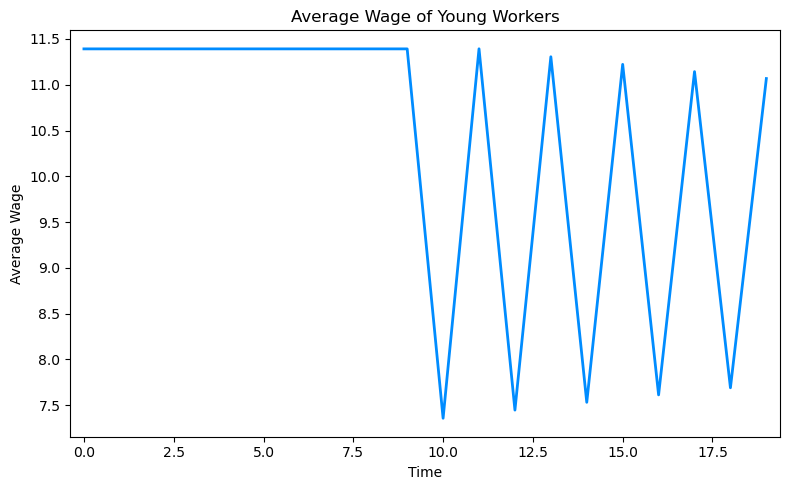

In [9]:
param_spec = {
    "A":        {"value": par.A,  "bounds": (0.5, 5.0),  "active": True},
    "N_y":      {"value": par.N_y,   "bounds": (1, 100),    "active": True},
    "alpha":    {"value": par.alpha,  "bounds": (0.01, 0.99),  "active": True},
    "theta_l_y":{"value": par.theta_l_y,  "bounds": (0.1, 5.0),  "active": True},
    "theta_h_y":{"value": par.theta_h_y,  "bounds": (0.1, 5.0),  "active": True},
    "theta_l_o":{"value": par.theta_l_o,  "bounds": (0.1, 5.0),  "active": True},
    "theta_h_o":{"value": par.theta_h_o,  "bounds": (0.1, 5.0),  "active": True},
    "mu_y":     {"value": par.mu_y,  "bounds": (1.0, 10.0), "active": True},
    "mu_o":     {"value": par.mu_o,  "bounds": (0.1, 10.0), "active": False},
    "rho_h":    {"value": par.rho_h,  "bounds": (0.1, 0.99), "active": False},
    "rho_l":    {"value": par.rho_l,  "bounds": (0.1, 0.99), "active": True},
    "c":        {"value": par.c,  "bounds": (0.1, 10.0),  "active": True},
}


active_names = [k for k, v in param_spec.items() if v["active"]]
x0 = np.array([param_spec[k]["value"] for k in active_names], dtype=float)
bounds = [param_spec[k]["bounds"] for k in active_names]

def apply_params(par, names, values):
    for name, val in zip(names, values):
        setattr(par, name, float(val))
    return par

def objective(x):
    # Initialize all non-active parameters to their default values
    for name, spec in param_spec.items():
        if not spec["active"]:
            setattr(par, name, spec["value"])

    apply_params(par, active_names, x)

    model.solve(do_print=False)

    if not constraints(par, model.sol, t=0, do_print=True):
        return 1e12

    parameter_names = ["rho_h"]
    parameter_values = [1.0]

    model.simulate_par_shock(parameter_names, parameter_values)

    return model.sim.avg_wage_young[10] - model.sim.avg_wage_young[11]


def optimize_and_plot(fixed_params = False):
    if fixed_params:
        result = minimize(
            objective,
            x0=x0_random,
            bounds=bounds,
            method="trust-constr",
            constraints=linear_constraint,
        )

    else:
        for i in range(optimizer_trials):

            x0_random = np.array([np.random.uniform(low, high) for (low, high) in bounds], dtype=float)
            x0_random[4] = max(x0_random[4], x0_random[3] + 0.1)
            x0_random[6] = max(x0_random[6], x0_random[5] + 0.1)

            result = minimize(
                objective,
                x0=x0_random,
                bounds=bounds,
                method="trust-constr",
                constraints=linear_constraint,
            )

            if result.fun < 0.0:
                break

            if i == optimizer_trials - 1:
                print("Warning: Optimization did not converge to a solution with negative objective value.")

    # --- write back optimized values ---
    optimized_values = result.x
    apply_params(par, active_names, optimized_values)

    print("Success:", result.success)
    print("Message:", result.message)
    print("Objective value:", result.fun)
    print("Optimized parameters:")
    for name in active_names:
        print("par." + name + " = ", getattr(par, name))

    # final solve/sim with optimal values
    model.solve()
    parameter_names = ["rho_h"]
    parameter_values = [1.0]
    model.simulate_par_shock(parameter_names, parameter_values)

    plot_series(model.sim.avg_wage_young, title="Average Wage of Young Workers", ylabel="Average Wage")

optimize_and_plot(fixed_params=False)